In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [8]:
methods = ['nearest', 'bilinear', 'bicubic', 'lanczos3']

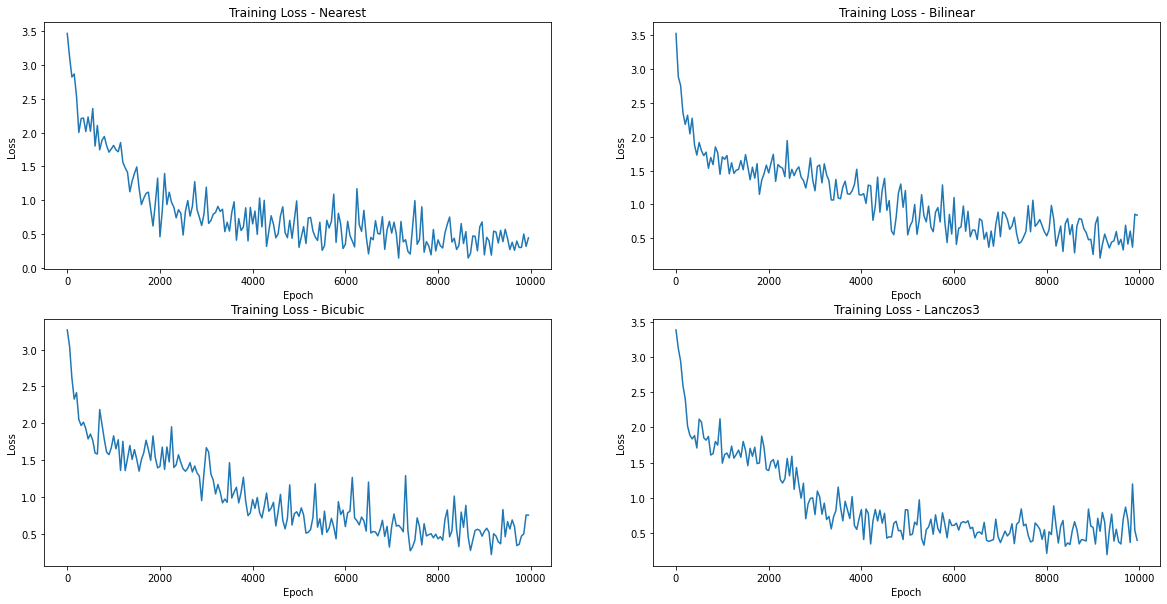

In [9]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 10]
fig, axs = plt.subplots(2, 2)
ax_list = [(0, 0), (0, 1), (1, 0), (1, 1)]

x_axis = np.reshape(np.arange(10000), (200, 50))[:, 0]

for i in range(len(methods)):
    with open(f'bayesian-train-test/performance_{methods[i]}.json', 'r') as f:
        performance = json.load(f)['loss']['training']
    performance = np.reshape(performance, (200, 50))
    
    axs[ax_list[i]].plot(x_axis, performance[:, -1])
    axs[ax_list[i]].set_title(f'Training Loss - {methods[i].capitalize()}')
    axs[ax_list[i]].set_xlabel('Epoch')
    axs[ax_list[i]].set_ylabel('Loss')

In [10]:
import pandas as pd
from collections import Counter
from scipy.special import softmax

In [11]:
def get_pred(arr):
    return max(k for k, v in Counter([np.argmax(x) for x in arr]).items() if v > 1)

def variation_ratio(X):
    probs = np.array([softmax(x) for x in X])
    n_passes = probs.shape[0]

    means = np.array([np.sum(c) / n_passes for c in probs.T])

    return 1 - means[np.argmax(means)]

In [12]:
accuracy = pd.DataFrame(np.zeros((4, 4)), index=methods, columns=methods)
var_ratio = pd.DataFrame(np.zeros((4, 4)), index=methods, columns=methods)
classes = np.linspace(0.25, 1, num=31)

for method_1 in methods:
    with open(f'bayesian-train-test/tests_{method_1}.json', 'r') as f:
        tests = json.load(f)
        
    for method_2 in methods:
        method_2_tests = [x for x in tests['runs'] if x['method'] == method_2]
        preds = [get_pred(x['logits']) for x in method_2_tests]
        var_ratios = [variation_ratio(x['logits']) for x in method_2_tests]
        
        correct = 0
        for i in range(len(preds)):
            if classes[preds[i]] == method_2_tests[i]['sf']:
                correct += 1
        
        accuracy[method_2][method_1] = correct / len(preds)
        var_ratio[method_2][method_1] = np.mean(var_ratios)
        
        print(f'{method_1} predicting {method_2}: {correct / len(preds)}, uncertainty: {np.mean(var_ratios)}')

nearest predicting nearest: 0.8869677419354839, uncertainty: 0.09610375692784857
nearest predicting bilinear: 0.6885161290322581, uncertainty: 0.25346741531470734
nearest predicting bicubic: 0.7148387096774194, uncertainty: 0.2270365992621856
nearest predicting lanczos3: 0.7169032258064516, uncertainty: 0.23768750874244265
bilinear predicting nearest: 0.6224516129032258, uncertainty: 0.2586810509241233
bilinear predicting bilinear: 0.6912258064516129, uncertainty: 0.24492768208553764
bilinear predicting bicubic: 0.7170322580645161, uncertainty: 0.2246929887848592
bilinear predicting lanczos3: 0.7139354838709677, uncertainty: 0.22930088562219111
bicubic predicting nearest: 0.6891612903225807, uncertainty: 0.1725009945583654
bicubic predicting bilinear: 0.7749677419354839, uncertainty: 0.16327410899095027
bicubic predicting bicubic: 0.7912258064516129, uncertainty: 0.14720412309602013
bicubic predicting lanczos3: 0.7843870967741935, uncertainty: 0.15327069412524388
lanczos3 predicting ne

In [13]:
accuracy

,nearest,bilinear,bicubic,lanczos3
nearest,0.886968,0.688516,0.714839,0.716903
bilinear,0.622452,0.691226,0.717032,0.713935
bicubic,0.689161,0.774968,0.791226,0.784387
lanczos3,0.794581,0.861032,0.873032,0.871226


In [14]:
var_ratio

,nearest,bilinear,bicubic,lanczos3
nearest,0.096104,0.253467,0.227037,0.237688
bilinear,0.258681,0.244928,0.224693,0.229301
bicubic,0.172501,0.163274,0.147204,0.153271
lanczos3,0.177449,0.154073,0.137880,0.140367
